# Resultados finales de la simulación de la poda

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_det_random = pd.read_csv('resultados_detalle_random.csv')
df_det_TPE = pd.read_csv('resultados_detalle_TPE.csv')

## Resultados detallados 

In [2]:
print("BÚSQUEDA ALEATORIA")
df_random = df_det_random[(df_det_random['T'] == 10) & (df_det_random['E'] == -0.1)].copy()
display(df_random)

print("ALGORITMO TPE")
df_TPE = df_det_TPE[(df_det_TPE['T'] == 5) & (df_det_TPE['E'] == -0.1)].copy()
display(df_TPE)

BÚSQUEDA ALEATORIA


,T,E,fold_cv,task_id,logloss_poda,logloss_real,logloss_perdido(%),n_iter_poda,n_iter_real,iter_ahorradas(%),sesgo_calibracion
100,10,-0.1,0,146820,0.039400,0.038271,2.9500,146182,1740856,91.6029,-0.119779
101,10,-0.1,0,168350,0.235516,0.233520,0.8547,142258,1704624,91.6546,-0.045382
102,10,-0.1,0,190392,0.374188,0.331513,12.8728,149401,2030996,92.6440,0.037291
103,10,-0.1,0,359956,0.295673,0.292846,0.9654,235691,1344127,82.4651,-0.056464
104,10,-0.1,0,359965,0.015906,0.015906,0.0000,697269,2178742,67.9967,-0.183477
105,10,-0.1,0,359975,0.021307,0.020519,3.8403,89050,866019,89.7173,-0.145525
106,10,-0.1,0,359980,0.067476,0.067476,0.0000,989150,3195868,69.0491,-0.146925
107,10,-0.1,1,168757,0.486913,0.483917,0.6191,104062,1089330,90.4472,0.134383
108,10,-0.1,1,168911,0.401516,0.395381,1.5517,227064,1078823,78.9526,0.127004
109,10,-0.1,1,359958,0.177909,0.174458,1.9781,106738,1203058,91.1278,0.032021


ALGORITMO TPE


,T,E,fold_cv,task_id,logloss_poda,logloss_real,logloss_perdido(%),n_iter_poda,n_iter_real,iter_ahorradas(%),sesgo_calibracion
20,5,-0.1,0,146820,0.039400,0.037995,3.6979,107319,1238041,91.3315,-0.081184
21,5,-0.1,0,168350,0.225816,0.225671,0.0643,259505,630490,58.8407,-0.070451
22,5,-0.1,0,190392,0.331528,0.317200,4.5170,113002,713336,84.1587,0.093678
23,5,-0.1,0,359956,0.287348,0.285494,0.6494,160692,441191,63.5777,-0.024419
24,5,-0.1,0,359965,0.016131,0.016131,0.0000,795605,849323,6.3248,-0.124352
25,5,-0.1,0,359975,0.021307,0.020512,3.8758,49922,288404,82.6903,-0.096902
26,5,-0.1,0,359980,0.066671,0.066671,-0.0000,1498315,1577750,5.0347,-0.167614
27,5,-0.1,1,168757,0.486913,0.479304,1.5875,65057,301394,78.4146,0.127885
28,5,-0.1,1,168911,0.398396,0.392326,1.5472,70958,467507,84.8220,0.070659
29,5,-0.1,1,359958,0.177909,0.170866,4.1219,67680,385852,82.4596,0.026009


In [3]:
# Estadísticas globales 
print("=== RandomSampler ===")
print(f"Ahorro medio:         {df_random['iter_ahorradas(%)'].mean():.2f} ± {df_random['iter_ahorradas(%)'].std():.2f}")
print(f"Degradación media:    {df_random['logloss_perdido(%)'].mean():.2f} ± {df_random['logloss_perdido(%)'].std():.2f}")
print(f"Datasets con deg=0:   {(df_random['logloss_perdido(%)'] == 0).sum()}")

print("\n=== TPESampler ===")
print(f"Ahorro medio:         {df_TPE['iter_ahorradas(%)'].mean():.2f} ± {df_TPE['iter_ahorradas(%)'].std():.2f}")
print(f"Degradación media:    {df_TPE['logloss_perdido(%)'].mean():.2f} ± {df_TPE['logloss_perdido(%)'].std():.2f}")
print(f"Datasets con deg=0:   {(df_TPE['logloss_perdido(%)'] == 0).sum()}")

=== RandomSampler ===
Ahorro medio:         86.88 ± 7.74
Degradación media:    2.14 ± 3.04
Datasets con deg=0:   4

=== TPESampler ===
Ahorro medio:         67.62 ± 29.52
Degradación media:    2.30 ± 2.30
Datasets con deg=0:   3


## Ahorro de iteraciones

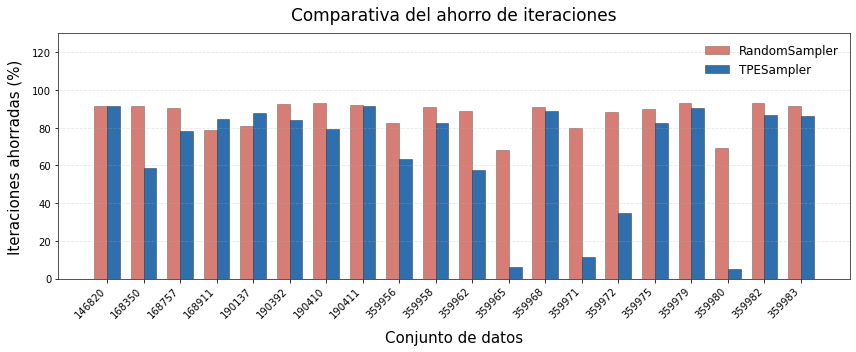

In [4]:
merged = pd.merge(df_random, df_TPE, on='task_id', suffixes=('_RS', '_TPE'))

orden = merged.sort_values('task_id')['task_id'].values
x = np.arange(len(orden))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.bar(x - width/2,
       merged.set_index('task_id').loc[orden, 'iter_ahorradas(%)_RS'],
       width, label='RandomSampler', color='#C0392B', alpha=0.65,
       edgecolor='#2C2C2A', linewidth=0.5)
ax.bar(x + width/2,
       merged.set_index('task_id').loc[orden, 'iter_ahorradas(%)_TPE'],
       width, label='TPESampler', color='#185FA5', alpha=0.9,
       edgecolor='#2C2C2A', linewidth=0.5)

for spine in ax.spines.values():
    spine.set_edgecolor('#2C2C2A')
    spine.set_linewidth(0.8)

ax.set_xticks(x)
ax.set_xticklabels([str(int(t)) for t in orden], rotation=45, ha='right', fontsize=10)
ax.set_xlabel('Conjunto de datos', labelpad=10, fontsize=15)
ax.set_ylabel('Iteraciones ahorradas (%)', labelpad=10, fontsize=15)
ax.set_title('Comparativa del ahorro de iteraciones', pad=13, fontsize=17)
ax.legend(frameon=False, fontsize=12)
ax.grid(True, axis='y', linestyle='--', alpha=0.3)
ax.set_ylim(0, 130)

plt.tight_layout()
#plt.savefig('barras_ahorro.png', bbox_inches='tight', facecolor='white', dpi=230)
plt.show()

## Pérdida de rendimiento

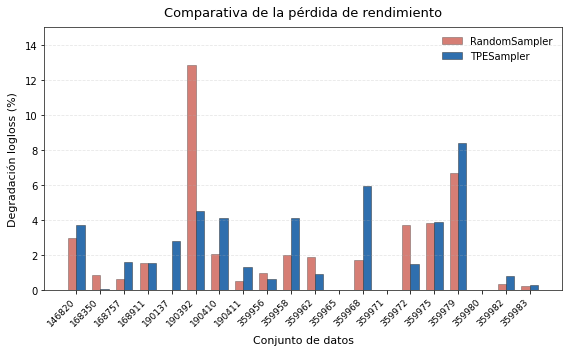

In [5]:
orden = merged.sort_values('task_id')['task_id'].values
x = np.arange(len(orden))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bars_rs = ax.bar(x - width/2, 
                  merged.set_index('task_id').loc[orden, 'logloss_perdido(%)_RS'],
                  width, label='RandomSampler', color='#C0392B', alpha=0.65,
                  edgecolor='#2C2C2A', linewidth=0.5)
bars_tpe = ax.bar(x + width/2,
                   merged.set_index('task_id').loc[orden, 'logloss_perdido(%)_TPE'],
                   width, label='TPESampler', color='#185FA5', alpha=0.9,
                   edgecolor='#2C2C2A', linewidth=0.5)

for spine in ax.spines.values():
    spine.set_edgecolor('#2C2C2A')
    spine.set_linewidth(0.8)

ax.set_xticks(x)
ax.set_xticklabels([str(int(t)) for t in orden], rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Conjunto de datos', labelpad=7, fontsize=11)
ax.set_ylabel('Degradación logloss (%)', labelpad=7, fontsize=11)
ax.set_title('Comparativa de la pérdida de rendimiento', pad=11, fontsize=13)
ax.axhline(0, color='#2C2C2A', linewidth=0.8, linestyle='--')
ax.legend(frameon=False, fontsize=10)
ax.grid(True, axis='y', linestyle='--', alpha=0.3)

ax.set_ylim(0, 15)

plt.tight_layout()
#plt.savefig('barras_degradacion_datasets.png', bbox_inches='tight', facecolor='white', dpi=230)
plt.show()